In [1]:
import pandas as pd
import numpy as np

In [2]:
# import the dataset

dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [3]:
# check the null values
dataset.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
# remove the unused features(columns)
dataset = dataset.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender'], axis=1)
dataset.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1


In [5]:
# input and output features

input_data = dataset.iloc[:, :-1]
output_data = dataset.iloc[:, -1]

In [6]:
# scale the input data

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

In [7]:
input_data = pd.DataFrame(ss.fit_transform(input_data), columns=input_data.columns)
input_data.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687


In [8]:
# train test split the data

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42)

## Now use the ANN (Tensorflow and Keras)

In [9]:
import tensorflow as tf

In [10]:
from keras.layers import Dense
from keras.models import Sequential

In [11]:
ann = Sequential()


In [12]:
# create the hidden layers, taking the 6 layers because input_data.shape has 8 features so we take less then 8
ann.add(Dense(units=6, input_dim=8, activation='relu'))
ann.add(Dense(units=4, activation='relu'))
ann.add(Dense(units=2, activation='relu'))
ann.add(Dense(units=1, activation='sigmoid'))  # output layer

d:\anaconda3\envs\tf_310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# compile the model
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
x_train.shape

(8000, 8)

In [15]:
# train the model, we will use batch size  of 100 means 80 in each batch because we have 8000 rows
ann.fit(x_train, y_train, batch_size=100, epochs=50) # epochs 20 means how many times we will train the model

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4946 - loss: 0.7044
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7877 - loss: 0.6673
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7965 - loss: 0.6467
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7905 - loss: 0.6302
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7987 - loss: 0.6122
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7975 - loss: 0.5982
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7863 - loss: 0.5897
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7997 - loss: 0.5721
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8003 - loss: 0.5601
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8043 - loss: 0.5463
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8021 - loss: 0.5403
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8075 - lo

In [16]:
# check the accuracy of the model

from sklearn.metrics import accuracy_score

In [17]:
prd = ann.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [18]:
# now prepare the output 

prd_data = []

for i in prd:
    if i >= 0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)


In [19]:
accuracy_score(y_test, prd_data)

0.85

In [20]:
# now check the training accuracy
accuracy_score(y_train, ann.predict(x_train) > 0.5)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.843875

In [21]:
# now test the model with data

x_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
6252,-0.564197,-0.660018,-0.695982,0.324119,0.807737,-1.547768,-1.030670,-1.013811
4684,-0.284834,0.388871,-1.387538,-1.225848,0.807737,0.646092,0.970243,0.804921
1731,-0.512463,0.484225,-0.350204,-1.225848,0.807737,0.646092,-1.030670,-0.722147
4742,-1.495407,1.914528,1.032908,0.683816,0.807737,0.646092,0.970243,1.227481
4521,-0.936681,-1.136786,0.687130,0.777477,-0.911583,0.646092,0.970243,0.253524
...,...,...,...,...,...,...,...,...
6412,-0.502117,1.342407,-0.004426,0.349118,-0.911583,-1.547768,0.970243,-0.957298
8285,-0.429689,-1.327494,1.724464,-1.225848,-0.911583,-1.547768,0.970243,0.170498
7853,0.822271,0.770285,0.687130,-1.225848,-0.911583,0.646092,-1.030670,-1.160142
1095,0.429093,-0.946079,-0.350204,-1.225848,-0.911583,0.646092,-1.030670,-0.405759


In [22]:
prd1 = ann.predict(np.array([[-0.564197,-0.660018,-0.695982,0.324119,0.807737,-1.547768,-1.030670,-1.013811]]))
if prd1 >= 0.5:
    print("Customer will leave the bank 1")
else:
    print("Customer will not leave the bank 0")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Customer will not leave the bank 0


In [23]:
# lets verify
y_test.iloc[0]  # 1 means customer will leave the bank

np.int64(0)

## Draw the ANN

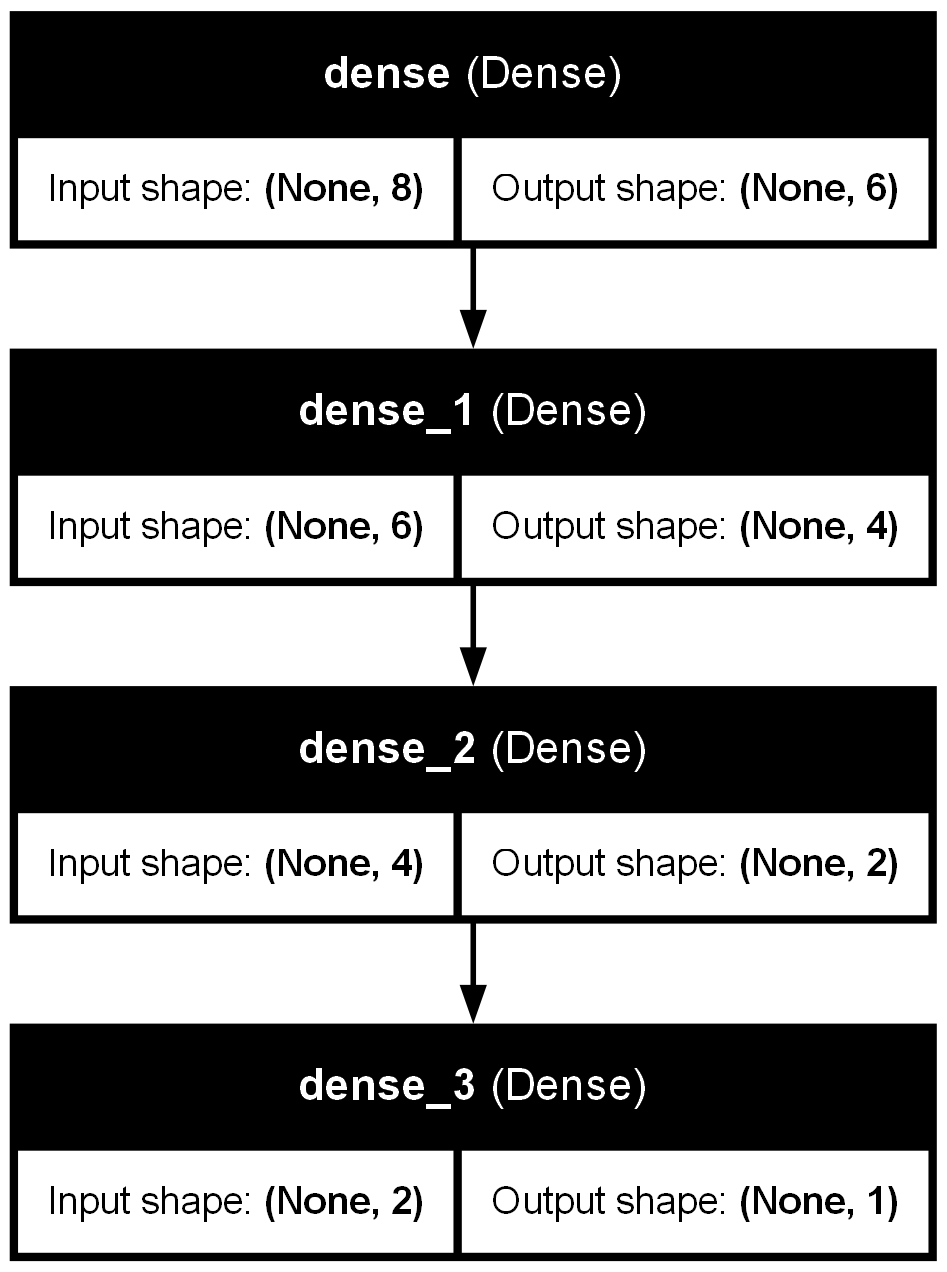

In [24]:
from keras.utils import plot_model

plot_model(ann, show_shapes=True, show_layer_names=True, to_file=r'D:\MCA Cource Material\Data Science Programming\AI\06 Deep Learning\ann_model.png')